# 13 TCN Fast-Feature Model

This notebook tests a `Temporal Convolutional Network (TCN)` on the same `fast_current` feature set used in the earlier transformer notebooks.

The goal is to answer a clean architecture question:

- if we keep the panel setup and fast features fixed,
- does a TCN model fit volatility better than the transformer family did?

The notebook also tracks low-volatility error and low-volatility bias, since the recent discussion focused on how hard it is to model the valleys of the volatility curve.

## TCN vs 1D CNN

A `TCN` is a **special kind of 1D CNN** built for sequence forecasting.

The main differences are:

- `causal convolutions`: the prediction at time `t` is allowed to use only times `<= t`,
- `dilated convolutions`: the receptive field grows quickly without making the network extremely deep,
- `residual blocks`: the model is easier to train on longer sequences.

So the right way to think about it is: **every TCN is a 1D CNN, but not every 1D CNN is a TCN**.

In [1]:
from pathlib import Path
import copy
import math
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

PROJECT_DIR = Path('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project')
DATA_DIR = PROJECT_DIR / 'data'
FIGURE_DIR = PROJECT_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DF_PATH = DATA_DIR / 'model_df_2016_2025.csv.gz'

try:
    mpl_dir = PROJECT_DIR / '.matplotlib'
    mpl_dir.mkdir(exist_ok=True)
except PermissionError:
    mpl_dir = Path('/tmp/erdos_vol_pred_runtime/.matplotlib')
    mpl_dir.mkdir(parents=True, exist_ok=True)

os.environ['MPLCONFIGDIR'] = str(mpl_dir)

assert MODEL_DF_PATH.exists(), f'Run 01_data_download_and_features.ipynb first: {MODEL_DF_PATH}'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

DEVICE

device(type='mps')

## Data and fast feature set

This keeps the same `fast_current` feature list used by the earlier fast-feature transformer experiments so that the model comparison stays as fair as possible.

In [2]:
model_df = pd.read_csv(MODEL_DF_PATH, parse_dates=['Date']).sort_values(['Ticker', 'Date']).reset_index(drop=True)

feature_list = [
    'abs_return', 'squared_return', 'high_low_log_range', 'log_volume',
    'realized_vol_5d', 'realized_vol_21d', 'realized_vol_63d',
    'hist_vol_5d', 'hist_vol_21d',
    'volume_zscore_21d', 'abs_return_mean_5d', 'parkinson_vol_5d',
    'mkt_SPY_proxy_return', 'mkt_SPY_proxy_hist_vol_5d',
    'mkt_QQQ_proxy_return', 'mkt_QQQ_proxy_hist_vol_21d',
    'mkt_IWM_proxy_return',
    'macro_^VIX_proxy_level_zscore_21d', 'macro_^TNX_proxy_return',
    'macro_HYG_proxy_return', 'macro_LQD_proxy_return',
    'volume_zscore_5d', 'return_mean_5d', 'realized_vol_10d', 'parkinson_vol_21d',
    'mkt_SPY_proxy_range', 'mkt_QQQ_proxy_range', 'mkt_IWM_proxy_range',
    'macro_^VIX_proxy_return', 'macro_^VIX_proxy_hist_vol_5d', 'macro_^VIX_proxy_range',
]

selected_tickers = ['AAPL', 'MSFT', 'NVDA', 'JPM', 'XOM']
target_columns = ['Date', 'Ticker', 'fvol_5d', 'log_fvol_5d']
train_end_year = 2023
validation_year = 2024
test_year = 2025

model_config = {
    'lookback': 90,
    'channels': [64, 64, 64, 64, 64],
    'kernel_size': 3,
    'dropout': 0.2,
    'ticker_embedding_dim': 8,
    'batch_size': 512,
    'epochs': 30,
    'patience': 6,
    'learning_rate': 3e-4,
    'weight_decay': 1e-3,
}

pd.DataFrame({'feature_count': [len(feature_list)], 'lookback': [model_config['lookback']]})

,feature_count,lookback
0,31,90


## Dataset and TCN model

The TCN uses causal dilated convolutions, so its final time step sees a wide time window without leaking future information.

In [3]:
class RollingSequenceDataset(Dataset):
    def __init__(self, grouped_data, ticker_to_idx, lookback, allowed_years):
        self.grouped_data = grouped_data
        self.ticker_to_idx = ticker_to_idx
        self.lookback = lookback
        self.allowed_years = set(allowed_years)
        self.samples = []
        for ticker, panel in grouped_data.items():
            for end_idx in range(lookback - 1, len(panel['dates'])):
                if panel['dates'][end_idx].year in self.allowed_years:
                    self.samples.append((ticker, end_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ticker, end_idx = self.samples[idx]
        panel = self.grouped_data[ticker]
        start_idx = end_idx - self.lookback + 1
        x = panel['features'][start_idx:end_idx + 1]
        return {
            'x': torch.tensor(x, dtype=torch.float32),
            'ticker_idx': torch.tensor(self.ticker_to_idx[ticker], dtype=torch.long),
            'y_log': torch.tensor(panel['target_log'][end_idx], dtype=torch.float32),
            'y_vol': torch.tensor(panel['target_vol'][end_idx], dtype=torch.float32),
            'date': panel['dates'][end_idx].strftime('%Y-%m-%d'),
            'ticker': ticker,
        }

class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1):
        super().__init__()
        self.left_padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, dilation=dilation)

    def forward(self, x):
        x = nn.functional.pad(x, (self.left_padding, 0))
        return self.conv(x)

class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout):
        super().__init__()
        self.conv1 = CausalConv1d(in_channels, out_channels, kernel_size=kernel_size, dilation=dilation)
        self.conv2 = CausalConv1d(out_channels, out_channels, kernel_size=kernel_size, dilation=dilation)
        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.downsample = nn.Conv1d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else None

    def forward(self, x):
        residual = x if self.downsample is None else self.downsample(x)
        out = self.dropout(self.activation(self.conv1(x)))
        out = self.dropout(self.activation(self.conv2(out)))
        return self.activation(out + residual)

class TCNVolatilityModel(nn.Module):
    def __init__(self, input_dim, num_tickers, channels, kernel_size, dropout, ticker_embedding_dim):
        super().__init__()
        layers = []
        in_channels = input_dim
        for i, out_channels in enumerate(channels):
            dilation = 2 ** i
            layers.append(TemporalBlock(in_channels, out_channels, kernel_size=kernel_size, dilation=dilation, dropout=dropout))
            in_channels = out_channels
        self.tcn = nn.Sequential(*layers)
        self.ticker_embedding = nn.Embedding(num_tickers, ticker_embedding_dim)
        self.head = nn.Sequential(
            nn.Linear(channels[-1] + ticker_embedding_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x, ticker_idx):
        x = x.transpose(1, 2)
        encoded = self.tcn(x)
        sequence_repr = encoded[:, :, -1]
        ticker_repr = self.ticker_embedding(ticker_idx)
        output = self.head(torch.cat([sequence_repr, ticker_repr], dim=1)).squeeze(-1)
        return output

def prepare_data(feature_list, lookback, batch_size):
    experiment_df = model_df[target_columns + feature_list].copy().sort_values(['Ticker', 'Date']).reset_index(drop=True)
    train_mask = experiment_df['Date'].dt.year <= train_end_year
    feature_mean = experiment_df.loc[train_mask, feature_list].mean()
    feature_std = experiment_df.loc[train_mask, feature_list].std().replace(0, 1).fillna(1)
    experiment_df[feature_list] = (experiment_df[feature_list] - feature_mean) / feature_std
    ticker_levels = sorted(experiment_df['Ticker'].unique())
    ticker_to_idx = {ticker: idx for idx, ticker in enumerate(ticker_levels)}
    grouped_panels = {}
    for ticker, group in experiment_df.groupby('Ticker', sort=True):
        group = group.sort_values('Date').reset_index(drop=True)
        grouped_panels[ticker] = {
            'dates': group['Date'].tolist(),
            'features': group[feature_list].to_numpy(dtype=np.float32),
            'target_log': group['log_fvol_5d'].to_numpy(dtype=np.float32),
            'target_vol': group['fvol_5d'].to_numpy(dtype=np.float32),
        }
    return {
        'ticker_levels': ticker_levels,
        'train_loader': DataLoader(RollingSequenceDataset(grouped_panels, ticker_to_idx, lookback, range(2016, train_end_year + 1)), batch_size=batch_size, shuffle=True, num_workers=0),
        'val_loader': DataLoader(RollingSequenceDataset(grouped_panels, ticker_to_idx, lookback, [validation_year]), batch_size=batch_size, shuffle=False, num_workers=0),
        'test_loader': DataLoader(RollingSequenceDataset(grouped_panels, ticker_to_idx, lookback, [test_year]), batch_size=batch_size, shuffle=False, num_workers=0),
        'num_tickers': len(ticker_levels),
    }

def run_epoch(model, dataloader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    total_items = 0
    for batch in dataloader:
        x = batch['x'].to(DEVICE)
        ticker_idx = batch['ticker_idx'].to(DEVICE)
        y_log = batch['y_log'].to(DEVICE)
        with torch.set_grad_enabled(is_train):
            pred = model(x, ticker_idx)
            loss = torch.mean((pred - y_log) ** 2)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        total_items += batch_size
    return total_loss / total_items

@torch.no_grad()
def predict_dataset(model, dataloader):
    model.eval()
    rows = []
    for batch in dataloader:
        x = batch['x'].to(DEVICE)
        ticker_idx = batch['ticker_idx'].to(DEVICE)
        pred_log = model(x, ticker_idx).detach().cpu().numpy()
        pred_vol = np.exp(np.clip(pred_log, -6.0, 6.0))
        y_vol = batch['y_vol'].detach().cpu().numpy()
        for date, ticker, actual, prediction in zip(batch['date'], batch['ticker'], y_vol, pred_vol):
            rows.append({'Date': pd.to_datetime(date), 'Ticker': ticker, 'fvol_5d': float(actual), 'prediction': float(prediction)})
    return pd.DataFrame(rows)

def evaluate(prediction_df):
    y_true = np.asarray(prediction_df['fvol_5d'], dtype=float)
    y_pred = np.clip(np.asarray(prediction_df['prediction'], dtype=float), 1e-8, None)
    errors = y_true - y_pred
    corr = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan
    low_cut = np.quantile(y_true, 0.20)
    low_mask = y_true <= low_cut
    low_errors = y_pred[low_mask] - y_true[low_mask]
    return {
        'rmse': float(np.sqrt(np.mean(errors ** 2))),
        'mae': float(np.mean(np.abs(errors))),
        'qlike': float(np.mean(np.log(y_pred ** 2) + (y_true ** 2) / (y_pred ** 2))),
        'corr': float(corr),
        'low_vol_mae': float(np.mean(np.abs(low_errors))),
        'low_vol_bias': float(np.mean(low_errors)),
    }


## Train the TCN

This uses the same train/validation/test years as the other notebooks: `2016-2023` train, `2024` validation, `2025` test.

In [4]:
data = prepare_data(feature_list, lookback=model_config['lookback'], batch_size=model_config['batch_size'])
model = TCNVolatilityModel(
    input_dim=len(feature_list),
    num_tickers=data['num_tickers'],
    channels=model_config['channels'],
    kernel_size=model_config['kernel_size'],
    dropout=model_config['dropout'],
    ticker_embedding_dim=model_config['ticker_embedding_dim'],
).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=model_config['learning_rate'], weight_decay=model_config['weight_decay'])

best_state = None
best_val_loss = float('inf')
best_epoch = None
epochs_without_improvement = 0
history_rows = []

for epoch in range(1, model_config['epochs'] + 1):
    train_loss = run_epoch(model, data['train_loader'], optimizer=optimizer)
    val_loss = run_epoch(model, data['val_loader'], optimizer=None)
    history_rows.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})
    print(f"epoch {epoch}/{model_config['epochs']} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    if epochs_without_improvement >= model_config['patience']:
        print(f"early stopping at epoch {epoch}. Best epoch: {best_epoch}.")
        break

model.load_state_dict(best_state)
history_df = pd.DataFrame(history_rows)
history_df

epoch 1/30 | train_loss=0.654706 | val_loss=0.262120


epoch 2/30 | train_loss=0.237512 | val_loss=0.252594


epoch 3/30 | train_loss=0.225745 | val_loss=0.249545


epoch 4/30 | train_loss=0.218457 | val_loss=0.247066


epoch 5/30 | train_loss=0.212823 | val_loss=0.246315


...

epoch 8/30 | train_loss=0.196841 | val_loss=0.248654


epoch 9/30 | train_loss=0.192860 | val_loss=0.248257


epoch 10/30 | train_loss=0.188627 | val_loss=0.248666


epoch 11/30 | train_loss=0.185518 | val_loss=0.249041
early stopping at epoch 11. Best epoch: 5.


,epoch,train_loss,val_loss
0,1,0.654706,0.262120
1,2,0.237512,0.252594
2,3,0.225745,0.249545
3,4,0.218457,0.247066
4,5,0.212823,0.246315
5,6,0.207740,0.248487
6,7,0.202378,0.247799
7,8,0.196841,0.248654
8,9,0.192860,0.248257
9,10,0.188627,0.248666


In [5]:
val_predictions = predict_dataset(model, data['val_loader'])
test_predictions = predict_dataset(model, data['test_loader'])
val_metrics = evaluate(val_predictions)
test_metrics = evaluate(test_predictions)
metric_df = pd.DataFrame([
    {'split': 'validation', **val_metrics},
    {'split': 'test', **test_metrics},
])
metric_df

,split,rmse,mae,qlike,corr,low_vol_mae,low_vol_bias
0,validation,0.142037,0.084448,-1.626274,0.433983,0.077569,0.075882
1,test,0.163370,0.097703,-1.330179,0.479959,0.081102,0.079298


## Decile table

This is useful for checking whether the TCN still lifts the lowest-volatility deciles too much.

In [6]:
test_decile_df = test_predictions.copy()
test_decile_df['actual_decile'] = pd.qcut(test_decile_df['fvol_5d'], q=10, labels=False, duplicates='drop')
test_decile_df.groupby('actual_decile', as_index=False).agg(actual_mean=('fvol_5d','mean'), predicted_mean=('prediction','mean'))

,actual_decile,actual_mean,predicted_mean
0,0,0.083271,0.170360
1,1,0.122678,0.194180
2,2,0.150164,0.204298
3,3,0.175348,0.214480
4,4,0.201213,0.223059
5,5,0.230242,0.234149
6,6,0.262382,0.245814
7,7,0.304798,0.267464
8,8,0.381788,0.287542
9,9,0.685255,0.354831


## Five-stock plot

This plot makes it easy to judge whether the TCN looks faster, smoother, or more valley-sensitive than the transformer family did.

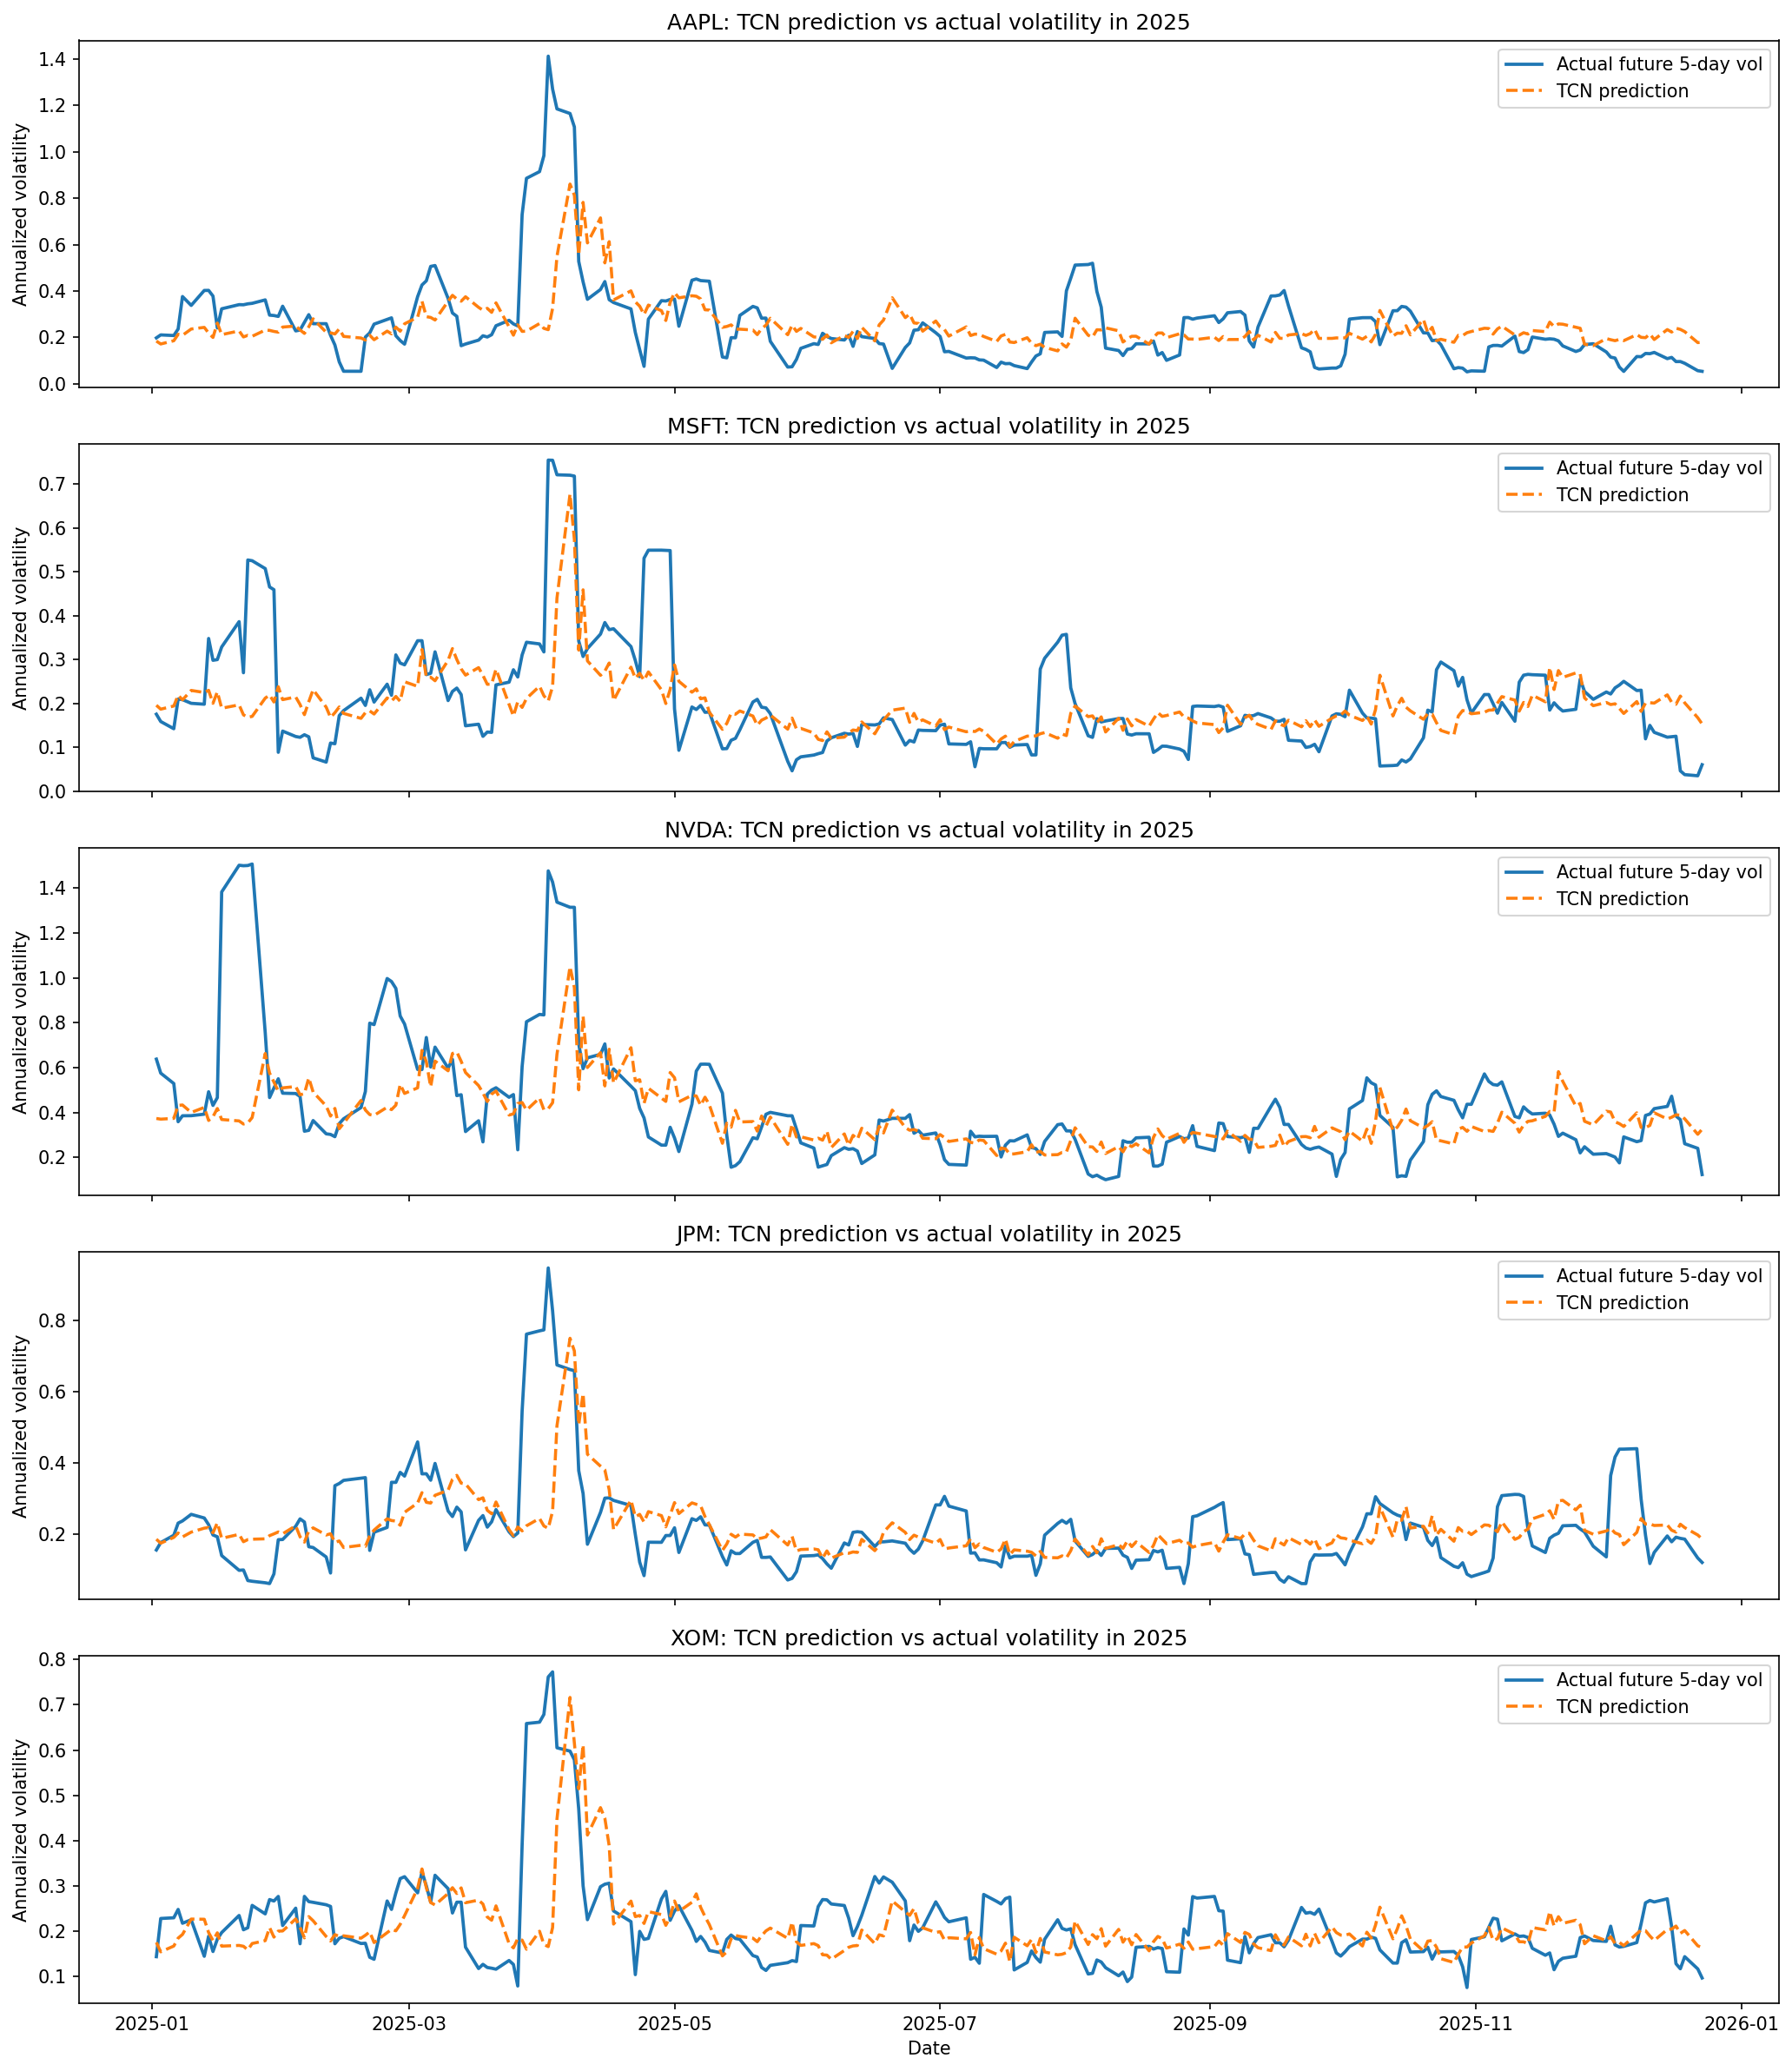

PosixPath('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project/figures/tcn_fast_feature_5stocks.png')

In [7]:
fig, axes = plt.subplots(len(selected_tickers), 1, figsize=(14, 16), sharex=True)

for ax, ticker in zip(axes, selected_tickers):
    stock_plot_df = test_predictions[test_predictions['Ticker'] == ticker].sort_values('Date')
    ax.plot(stock_plot_df['Date'], stock_plot_df['fvol_5d'], label='Actual future 5-day vol', linewidth=1.8)
    ax.plot(stock_plot_df['Date'], stock_plot_df['prediction'], label='TCN prediction', linestyle='--', linewidth=1.7)
    ax.set_title(f'{ticker}: TCN prediction vs actual volatility in 2025')
    ax.set_ylabel('Annualized volatility')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Date')
plt.tight_layout()

plot_path = FIGURE_DIR / 'tcn_fast_feature_5stocks.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(plot_path)))

plot_path

## How to interpret the result

The TCN is promising if it does one or more of these things:

- stays competitive on overall `RMSE / MAE / QLIKE`,
- improves `corr`,
- lowers `low_vol_mae` or `low_vol_bias`,
- and visually reacts a bit more naturally to the volatility cooldown phases.